# Frozen benchmark v0 (legacy)

This notebook is a **frozen snapshot** of the residual-correction MVP for comparison against later methodology changes.

- **Do not treat this as the active experiment.** Continue work in [`../residual_prediction.ipynb`](../residual_prediction.ipynb).
- Methodology, overall metrics, and per-horizon metrics are recorded in [`residual_prediction_v0_benchmark.md`](residual_prediction_v0_benchmark.md).

**Preliminary caveat:** these results use a train/test split by **target actualized month (`date`)**, not by **forecast origin**. Treat metrics as a reproducible baseline, not production-grade evaluation.


# XGBoost residual correction MVP

Correct time-series forecast errors for `TARGET_GENERIC_EN` products.

- **Baseline features:** forecast, horizon, calendar, sales lags, product attrs
- **+ Business features:** last-complete-6-month event and activity counts (leakage-safe vs forecast origin)
- Notebook-only; does not write back to `results/`

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBRegressor

_root = Path.cwd().resolve()
if _root.name == "notebooks":
    _src = _root.parent / "src"
    _results = _root.parent / "src" / "data" / "results"
else:
    _src = _root / "src"
    _results = _root / "src" / "data" / "results"
if str(_src) not in sys.path:
    sys.path.insert(0, str(_src))

from pkg.db.query.sales import load_sales_data
from pkg.db.query.dim_product import load_dim_product
from pkg.db.query.constants import TARGET_GENERIC_EN
from pkg.db.query.event_profile import load_event_count_by_product
from pkg.db.query.activity import load_activity_count_by_product

RESULTS_DIR = _results
print("results:", RESULTS_DIR)

# Incomplete Shamsi months to exclude from sales, forecasts, and training
INCOMPLETE_SHAMSI_MONTHS = {140505}


results: C:\Users\Mohajeri.K\MyProjects\Forecast\src\data\results


## Helpers (Shamsi month arithmetic)

In [2]:
def shamsi_add_months(ym: int, n: int) -> int:
    y, m = divmod(int(ym), 100)
    idx = y * 12 + (m - 1) + n
    y2, m0 = divmod(idx, 12)
    return y2 * 100 + (m0 + 1)


def shamsi_month_diff(ym_a: int, ym_b: int) -> int:
    """Months from ym_b to ym_a (ym_a - ym_b)."""
    ya, ma = divmod(int(ym_a), 100)
    yb, mb = divmod(int(ym_b), 100)
    return (ya * 12 + ma) - (yb * 12 + mb)


def last_complete_6m(origin_ym: int) -> tuple[int, int]:
    """Inclusive Shamsi window: origin-6 .. origin-1."""
    end = shamsi_add_months(origin_ym, -1)
    start = shamsi_add_months(origin_ym, -6)
    return start, end


assert last_complete_6m(140501) == (140407, 140412)
print("ok", last_complete_6m(140501))

ok (140407, 140412)


## Load sales and target products

In [3]:
sales_df = load_sales_data()
sales_df["date"] = sales_df["date"].astype(int)
sales_df["sales"] = pd.to_numeric(sales_df["sales"], errors="coerce")
sales_df = sales_df[~sales_df["date"].isin(INCOMPLETE_SHAMSI_MONTHS)].copy()
print("excluded incomplete sales months:", sorted(INCOMPLETE_SHAMSI_MONTHS))

dim_product_df = load_dim_product()
target_products = dim_product_df[dim_product_df["GenericEN"].isin(TARGET_GENERIC_EN)].copy()
target_product_names = set(target_products["ProductTitleEN"].dropna().astype(str))

product_attrs = (
    target_products[["ProductTitleEN", "GenericEN", "Field", "ProductForm", "Provider"]]
    .drop_duplicates(subset=["ProductTitleEN"])
    .rename(columns={"ProductTitleEN": "product", "GenericEN": "generic"})
)

print("sales rows", len(sales_df), "target products", len(target_product_names))
product_attrs.head()

excluded incomplete sales months: [140505]
sales rows 30628 target products 69


,product,generic,Field,ProductForm,Provider
1,Maciza,Maciza,کاردیو متابولیک تزریقی,Pen,سیناژن
6,Xetarem,Xetarem,کانتراست مدیا,Vial,آلاشت
17,Fiorage M,Fiorage,زیبایی,Prefilled Syringe,اسپاد فارمد دارو
46,Lunaphil Volix,Lunaphil,زیبایی,Prefilled Syringe,اسپاد فارمد دارو
66,Beraksurf 4,Beraksurf,رسپیراتوری,Vial,پرسیس ژن


## Build forecast–actual panel

For each allowed quarter CSV, **extract each product's 15-month forecast**:
dedupe to one value per product–month, then keep that product's **last 15 months** in the file (history before the forecast is dropped).

Allowed files: `1403Q1`–`1403Q4`, `1404Q2`–`1404Q4`, `1405Q2`.
Then join actualized sales; overlapping quarter runs stay as separate rows.


In [4]:
# Explicit allowlist of usable TS forecast runs (excludes empty / placeholder quarters)
ALLOWED_FORECAST_QRTS = (
    "1403Q1",
    "1403Q2",
    "1403Q3",
    "1403Q4",
    "1404Q2",
    "1404Q3",
    "1404Q4",
    "1405Q2",
)
FORECAST_HORIZON_MONTHS = 15


def extract_product_forecast_window(df: pd.DataFrame, n_months: int = FORECAST_HORIZON_MONTHS) -> pd.DataFrame:
    """From one quarter CSV, extract each product's n-month forecast.

    Files may contain history before the forecast. For each product:
    1) collapse to one row per Shamsi month
    2) keep the last `n_months` months = the forecast window
    3) set origin = first month of that window, horizon = 1..n
    """
    meta_cols = [c for c in ("product_fa", "provider", "model", "dep", "status", "qrt") if c in df.columns]
    parts = []
    short = []
    for product, g in df.groupby("product", sort=False):
        agg_kw = {"forecast": ("forecast", "mean")}
        agg_kw.update({c: (c, "first") for c in meta_cols})
        row = g.groupby("date", as_index=False).agg(**agg_kw)
        row["product"] = product
        dates = sorted(row["date"].astype(int).tolist())
        if not dates:
            continue
        window = dates[-n_months:]
        if len(window) < n_months:
            short.append((product, len(window)))
        origin = int(window[0])
        gg = row[row["date"].isin(window)].copy()
        gg["origin"] = origin
        gg["horizon"] = [shamsi_month_diff(int(d), origin) + 1 for d in gg["date"]]
        parts.append(gg)
    out = pd.concat(parts, ignore_index=True) if parts else df.iloc[0:0].copy()
    if short:
        print(f"  products with fewer than {n_months} months: {len(short)} (kept available months)")
    return out


def load_forecast_csvs(results_dir: Path, allowed_qrts=ALLOWED_FORECAST_QRTS) -> pd.DataFrame:
    """Load allowed quarter CSVs and extract each product's 15-month forecast."""
    frames = []
    missing = []
    for qrt in allowed_qrts:
        csv_path = results_dir / qrt / f"{qrt}_total_forecast.csv"
        if not csv_path.exists():
            missing.append(str(csv_path))
            continue
        df = pd.read_csv(csv_path)
        df["date"] = df["date"].astype(int)
        df["forecast"] = pd.to_numeric(df["forecast"], errors="coerce")
        df["qrt"] = qrt
        df = df[~df["date"].isin(INCOMPLETE_SHAMSI_MONTHS)].copy()
        print(f"{qrt}: raw rows={len(df)} products={df['product'].nunique()}")
        df = extract_product_forecast_window(df, FORECAST_HORIZON_MONTHS)
        months_per = df.groupby("product")["date"].nunique()
        print(
            f"{qrt}: forecast window rows={len(df)} "
            f"products={df['product'].nunique()} "
            f"months/product~{months_per.mean():.1f}"
        )
        frames.append(df)
    if missing:
        print("missing allowed forecast files:", missing)
    if not frames:
        raise FileNotFoundError(f"No allowed forecast CSVs under {results_dir}")
    print("loaded forecast qrts:", [f["qrt"].iloc[0] for f in frames])
    return pd.concat(frames, ignore_index=True)


forecast_df = load_forecast_csvs(RESULTS_DIR)
forecast_df = forecast_df[forecast_df["product"].isin(target_product_names)].copy()

sales_agg = (
    sales_df.groupby(["product", "date"], as_index=False)["sales"]
    .sum()
)

panel = forecast_df.merge(sales_agg, on=["product", "date"], how="inner")
panel = panel[~panel["date"].isin(INCOMPLETE_SHAMSI_MONTHS)].copy()
panel["residual"] = panel["sales"] - panel["forecast"]
panel = panel[(panel["horizon"] >= 1) & (panel["horizon"] <= FORECAST_HORIZON_MONTHS)].copy()

print("panel rows", len(panel), "products", panel["product"].nunique())
print("origins", sorted(panel["origin"].unique()))
print("qrts", sorted(panel["qrt"].unique()))
panel[["product", "qrt", "origin", "date", "horizon", "forecast", "sales", "residual"]].head()

1403Q1: raw rows=3679 products=247
  products with fewer than 15 months: 2 (kept available months)
1403Q1: forecast window rows=3679 products=247 months/product~14.9
1403Q2: raw rows=4305 products=285
1403Q2: forecast window rows=4275 products=285 months/product~15.0
1403Q3: raw rows=4485 products=299
1403Q3: forecast window rows=4485 products=299 months/product~15.0
1403Q4: raw rows=4470 products=298
1403Q4: forecast window rows=4470 products=298 months/product~15.0
1404Q2: raw rows=4700 products=334
  products with fewer than 15 months: 310 (kept available months)
1404Q2: forecast window rows=4700 products=334 months/product~14.1
1404Q3: raw rows=4746 products=339
  products with fewer than 15 months: 339 (kept available months)
1404Q3: forecast window rows=4746 products=339 months/product~14.0
1404Q4: raw rows=5026 products=359
  products with fewer than 15 months: 359 (kept available months)
1404Q4: forecast window rows=5026 products=359 months/product~14.0
1405Q2: raw rows=5404 pr

,product,qrt,origin,date,horizon,forecast,sales,residual
0,Aryotrust 150,1403Q1,140304,140304,1,6021.0,7689.0,1668.0
1,Aryotrust 150,1403Q1,140304,140305,2,6250.0,5550.0,-700.0
2,Aryotrust 150,1403Q1,140304,140306,3,6020.0,5631.0,-389.0
3,Aryotrust 150,1403Q2,140306,140306,1,6973.0,5631.0,-1342.0
4,Aryotrust 150,1403Q1,140304,140307,4,5943.0,4631.0,-1312.0


## Baseline features

In [5]:
sales_pivot = sales_agg.set_index(["product", "date"])["sales"]


def sales_at(product: str, ym: int) -> float:
    try:
        return float(sales_pivot.loc[(product, ym)])
    except KeyError:
        return np.nan


feat = panel.merge(product_attrs, on="product", how="left")
feat["month"] = feat["date"] % 100
feat["quarter"] = ((feat["month"] - 1) // 3) + 1

for lag in (1, 2, 3, 12):
    col = f"sales_lag_{lag}"
    feat[col] = [
        sales_at(p, shamsi_add_months(o, -lag))
        for p, o in zip(feat["product"], feat["origin"])
    ]

feat["sales_roll3"] = feat[["sales_lag_1", "sales_lag_2", "sales_lag_3"]].mean(axis=1)

BASELINE_FEATURES = [
    "forecast",
    "horizon",
    "month",
    "quarter",
    "sales_lag_1",
    "sales_lag_2",
    "sales_lag_3",
    "sales_lag_12",
    "sales_roll3",
    "model_enc",
    "field_enc",
    "form_enc",
    "provider_enc",
]

for col, src in [
    ("model_enc", "model"),
    ("field_enc", "Field"),
    ("form_enc", "ProductForm"),
    ("provider_enc", "Provider"),
]:
    enc = LabelEncoder()
    values = feat[src].fillna("__missing__").astype(str)
    feat[col] = enc.fit_transform(values)

print(feat[BASELINE_FEATURES + ["residual"]].describe().T[["count", "mean", "std"]].head(10))
feat.head(3)

               count          mean           std
forecast      5269.0  14851.479408  36580.793236
horizon       5279.0      7.140936      4.168240
month         5279.0      6.600493      3.461652
quarter       5279.0      2.549157      1.116125
sales_lag_1   5279.0  13482.255541  35134.522915
sales_lag_2   5279.0  14258.885016  36240.119155
sales_lag_3   5279.0  12106.448002  31438.676466
sales_lag_12  5174.0  11748.554117  31100.937496
sales_roll3   5279.0  13282.529519  33529.326867
model_enc     5279.0      0.984656      1.040826


,date,forecast,provider,model,dep,status,qrt,product,origin,horizon,...,quarter,sales_lag_1,sales_lag_2,sales_lag_3,sales_lag_12,sales_roll3,model_enc,field_enc,form_enc,provider_enc
0,140304,6021.0,آریوژن,ARIMA,انکولوژی بیولوژیک,بسته,1403Q1,Aryotrust 150,140304,1,...,2,10381.0,6856.0,2979.0,5044.0,6738.666667,0,1,8,0
1,140305,6250.0,آریوژن,ARIMA,انکولوژی بیولوژیک,بسته,1403Q1,Aryotrust 150,140304,2,...,2,10381.0,6856.0,2979.0,5044.0,6738.666667,0,1,8,0
2,140306,6020.0,آریوژن,ARIMA,انکولوژی بیولوژیک,بسته,1403Q1,Aryotrust 150,140304,3,...,2,10381.0,6856.0,2979.0,5044.0,6738.666667,0,1,8,0


## Business features (last complete 6 months per origin)

In [6]:
business_frames = []
for origin in sorted(feat["origin"].unique()):
    start_ym, end_ym = last_complete_6m(int(origin))
    print(f"origin={origin} window={start_ym}-{end_ym}")
    events = load_event_count_by_product(start_ym, end_ym)
    acts = load_activity_count_by_product(start_ym, end_ym)
    merged = events.merge(acts, on=["product", "generic"], how="outer")
    merged["origin"] = int(origin)
    business_frames.append(merged)

business_df = pd.concat(business_frames, ignore_index=True)
business_df["event_count_6m"] = business_df["event_count"].fillna(0)
business_df["activity_count_6m"] = business_df["activity_count"].fillna(0)

feat = feat.merge(
    business_df[["product", "origin", "event_count_6m", "activity_count_6m"]],
    on=["product", "origin"],
    how="left",
)
feat["event_count_6m"] = feat["event_count_6m"].fillna(0)
feat["activity_count_6m"] = feat["activity_count_6m"].fillna(0)
feat["event_per_sales"] = feat["event_count_6m"] / feat["sales_roll3"].replace(0, np.nan)
feat["activity_per_sales"] = feat["activity_count_6m"] / feat["sales_roll3"].replace(0, np.nan)
feat["event_per_sales"] = feat["event_per_sales"].fillna(0)
feat["activity_per_sales"] = feat["activity_per_sales"].fillna(0)

BUSINESS_FEATURES = [
    "event_count_6m",
    "activity_count_6m",
    "event_per_sales",
    "activity_per_sales",
]
ALL_FEATURES = BASELINE_FEATURES + BUSINESS_FEATURES

feat[BUSINESS_FEATURES].describe()

origin=140304 window=140210-140303
origin=140306 window=140212-140305
origin=140307 window=140301-140306
origin=140310 window=140304-140309
origin=140404 window=140310-140403
origin=140407 window=140401-140406
origin=140410 window=140404-140409
origin=140504 window=140410-140503


,event_count_6m,activity_count_6m,event_per_sales,activity_per_sales
count,5279.000000,5279.000000,5279.000000,5279.000000
mean,19.605986,5287.605418,0.139084,18.370026
std,24.015864,5873.512606,1.397615,418.367547
min,0.000000,0.000000,-39.000000,-27576.000000
25%,2.000000,1657.000000,0.000172,0.170459
50%,12.000000,2892.000000,0.002286,1.188122
75%,31.000000,7842.000000,0.039844,8.661963
max,128.000000,32296.000000,69.000000,6751.500000


## Train / test split and XGBoost models

Split by **actualized Shamsi month** (`date`): last 20% of distinct months in the panel are test; the rest are train. Forecast file (`qrt`) is not used for the split.


In [7]:
# Drop invalid labels; fill missing sales lags (new products / short history)
feat_model = feat.replace([np.inf, -np.inf], np.nan).dropna(
    subset=["residual", "forecast", "sales"]
).copy()
for c in ["sales_lag_1", "sales_lag_2", "sales_lag_3", "sales_lag_12", "sales_roll3"]:
    feat_model[c] = feat_model[c].fillna(0)

# Time split on actualized Shamsi months (data points), not forecast files
TEST_DATE_FRACTION = 0.2
unique_dates = sorted(feat_model["date"].astype(int).unique())
n_test_dates = max(1, int(round(len(unique_dates) * TEST_DATE_FRACTION)))
TEST_DATES = set(unique_dates[-n_test_dates:])
train_mask = ~feat_model["date"].isin(TEST_DATES)
test_mask = feat_model["date"].isin(TEST_DATES)

train_df = feat_model.loc[train_mask].copy()
test_df = feat_model.loc[test_mask].copy()
print(
    "dropped_nan_residual",
    len(feat) - len(feat_model),
    "feat_model",
    len(feat_model),
    "train",
    len(train_df),
    "test",
    len(test_df),
)
print(
    f"date split: {len(unique_dates)} months total, "
    f"test last {n_test_dates} ({TEST_DATE_FRACTION:.0%}) -> {sorted(TEST_DATES)}"
)
print("train date range", train_df["date"].min(), "..", train_df["date"].max())
print("test date range", test_df["date"].min(), "..", test_df["date"].max())
print("train qrts (files present)", sorted(train_df["qrt"].unique()))
print("test qrts (files present)", sorted(test_df["qrt"].unique()))
assert len(test_df) > 0, "empty test set"
assert train_df["residual"].notna().all() and np.isfinite(train_df["residual"]).all()

# Shorter horizons weigh more (h=1 -> 1.0, h=3 -> 1/3, h=12 -> 1/12)
train_df["sample_weight"] = 1.0 / train_df["horizon"].clip(lower=1).astype(float)
print(
    "sample_weight by horizon:",
    train_df.groupby("horizon")["sample_weight"].first().to_dict(),
)

XGB_PARAMS = dict(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1,
)


def fit_predict(features, train, test):
    model = XGBRegressor(**XGB_PARAMS)
    model.fit(
        train[features],
        train["residual"],
        sample_weight=train["sample_weight"],
    )
    pred = model.predict(test[features])
    return model, pred


model_base, pred_base = fit_predict(BASELINE_FEATURES, train_df, test_df)
model_biz, pred_biz = fit_predict(ALL_FEATURES, train_df, test_df)

test_df["pred_resid_base"] = pred_base
test_df["pred_resid_biz"] = pred_biz
test_df["forecast_adj_base"] = np.maximum(0, test_df["forecast"] + test_df["pred_resid_base"])
test_df["forecast_adj_biz"] = np.maximum(0, test_df["forecast"] + test_df["pred_resid_biz"])

print("models fitted")


dropped_nan_residual 10 feat_model 5269 train 4228 test 1041
date split: 25 months total, test last 5 (20%) -> [140412, 140501, 140502, 140503, 140504]
train date range 140304 .. 140411
test date range 140412 .. 140504
train qrts (files present) ['1403Q1', '1403Q2', '1403Q3', '1403Q4', '1404Q2', '1404Q3', '1404Q4']
test qrts (files present) ['1403Q3', '1403Q4', '1404Q2', '1404Q3', '1404Q4', '1405Q2']
sample_weight by horizon: {1: 1.0, 2: 0.5, 3: 0.3333333333333333, 4: 0.25, 5: 0.2, 6: 0.16666666666666666, 7: 0.14285714285714285, 8: 0.125, 9: 0.1111111111111111, 10: 0.1, 11: 0.09090909090909091, 12: 0.08333333333333333, 13: 0.07692307692307693, 14: 0.07142857142857142, 15: 0.06666666666666667}
models fitted


## Evaluation

In [8]:
def mape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mask = y_true != 0
    if mask.sum() == 0:
        return np.nan
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100


def wmape(y_true, y_pred):
    """Weighted MAPE: sum(|e|) / sum(|y|) * 100."""
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    denom = np.sum(np.abs(y_true))
    if denom == 0:
        return np.nan
    return float(np.sum(np.abs(y_true - y_pred)) / denom * 100)


def metrics_block(y_true, y_pred, label):
    return {
        "model": label,
        "rmse": float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "mae": float(mean_absolute_error(y_true, y_pred)),
        "mape": float(mape(y_true, y_pred)),
        "wmape": float(wmape(y_true, y_pred)),
    }


y = test_df["sales"]
overall = pd.DataFrame([
    metrics_block(y, test_df["forecast"], "base_ts"),
    metrics_block(y, test_df["forecast_adj_base"], "xgb_baseline"),
    metrics_block(y, test_df["forecast_adj_biz"], "xgb_baseline_plus_business"),
])
overall


,model,rmse,mae,mape,wmape
0,base_ts,27034.751925,9125.203650,4124.956311,65.420030
1,xgb_baseline,18856.377049,6800.395316,3514.431951,48.753111
2,xgb_baseline_plus_business,18755.836870,6730.817186,3240.014659,48.254294


In [9]:
rows = []
for h, g in test_df.groupby("horizon"):
    rows.append(metrics_block(g["sales"], g["forecast"], f"base_h{h}"))
    rows.append(metrics_block(g["sales"], g["forecast_adj_base"], f"xgb_base_h{h}"))
    rows.append(metrics_block(g["sales"], g["forecast_adj_biz"], f"xgb_biz_h{h}"))
by_horizon = pd.DataFrame(rows)
by_horizon["horizon"] = by_horizon["model"].str.extract(r"h(\d+)").astype(int)
by_horizon["kind"] = by_horizon["model"].str.replace(r"_h\d+", "", regex=True)
by_horizon.pivot(index="horizon", columns="kind", values="rmse")

kind,base,xgb_base,xgb_biz
horizon,,,
1,27722.563573,22097.395644,21889.921060
3,32631.974868,9140.784931,9437.587480
4,36496.472195,12732.464664,12398.090350
5,24494.402660,14265.981898,14127.114789
6,21594.389129,16109.589825,15944.299481
7,34003.687212,22278.220467,22150.884737
8,19734.548361,15433.095361,15328.642211
9,20996.745111,16776.221199,16632.638518
10,25802.166451,21759.190180,21673.892435


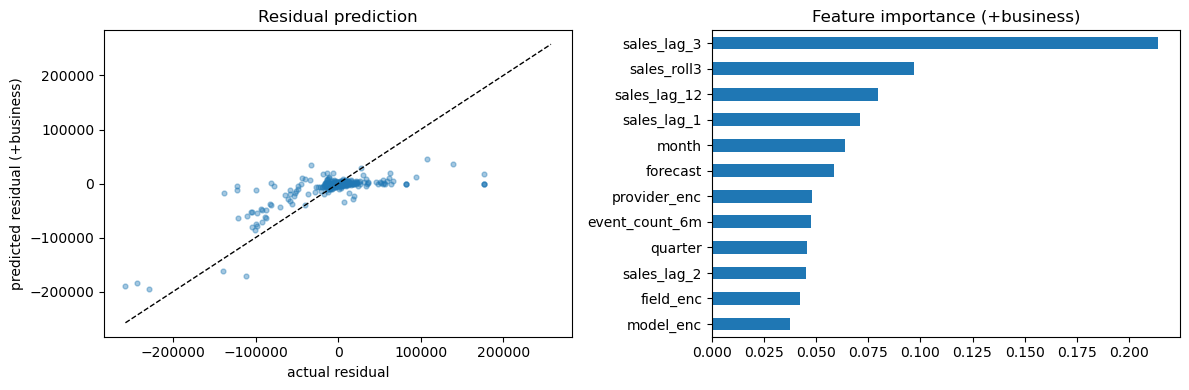

Best overall RMSE: xgb_baseline_plus_business (18755.84) vs base_ts (27034.75)
RMSE reduction vs base: 30.6%


,model,rmse,mae,mape,wmape
0,base_ts,27034.751925,9125.203650,4124.956311,65.420030
1,xgb_baseline,18856.377049,6800.395316,3514.431951,48.753111
2,xgb_baseline_plus_business,18755.836870,6730.817186,3240.014659,48.254294


In [10]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(test_df["residual"], test_df["pred_resid_biz"], alpha=0.4, s=12)
lim = np.nanmax(np.abs(test_df[["residual", "pred_resid_biz"]].to_numpy()))
axes[0].plot([-lim, lim], [-lim, lim], "k--", lw=1)
axes[0].set_xlabel("actual residual")
axes[0].set_ylabel("predicted residual (+business)")
axes[0].set_title("Residual prediction")

imp = pd.Series(model_biz.feature_importances_, index=ALL_FEATURES).sort_values()
imp.tail(12).plot(kind="barh", ax=axes[1])
axes[1].set_title("Feature importance (+business)")
plt.tight_layout()
plt.show()

winner = overall.sort_values("rmse").iloc[0]["model"]
base_rmse = overall.loc[overall["model"] == "base_ts", "rmse"].iloc[0]
best_rmse = overall["rmse"].min()
print(f"Best overall RMSE: {winner} ({best_rmse:.2f}) vs base_ts ({base_rmse:.2f})")
print(f"RMSE reduction vs base: {(base_rmse - best_rmse) / base_rmse * 100:.1f}%")
overall

## Product / quarter explorer

Pick a `product` and forecast `qrt`, then compare **sales**, base **TS** forecast, **ML** (baseline residual), and **biz ML** (baseline + events/activities).

Predictions are scored on the full cleaned panel (`feat_model`). Rows whose Shamsi `date` is in `TEST_DATES` are held-out; earlier dates are train (partly in-sample when viewed here).


In [11]:
import matplotlib.pyplot as plt

# Score full cleaned panel for interactive exploration
compare_df = feat_model.copy()
compare_df["pred_resid_base"] = model_base.predict(compare_df[BASELINE_FEATURES])
compare_df["pred_resid_biz"] = model_biz.predict(compare_df[ALL_FEATURES])
compare_df["ts"] = compare_df["forecast"]
compare_df["ml"] = np.maximum(0, compare_df["forecast"] + compare_df["pred_resid_base"])
compare_df["biz_ml"] = np.maximum(0, compare_df["forecast"] + compare_df["pred_resid_biz"])
compare_df["split"] = np.where(compare_df["date"].isin(TEST_DATES), "test", "train")

available_products = sorted(compare_df["product"].dropna().unique())
available_qrts = sorted(compare_df["qrt"].dropna().unique())
print(f"{len(available_products)} products, quarters: {available_qrts}")
compare_df[["product", "qrt", "date", "horizon", "sales", "ts", "ml", "biz_ml", "split"]].head()

63 products, quarters: ['1403Q1', '1403Q2', '1403Q3', '1403Q4', '1404Q2', '1404Q3', '1404Q4', '1405Q2']


,product,qrt,date,horizon,sales,ts,ml,biz_ml,split
0,Aryotrust 150,1403Q1,140304,1,7689.0,6021.0,6499.807892,6447.652588,train
1,Aryotrust 150,1403Q1,140305,2,5550.0,6250.0,6743.907745,6690.298645,train
2,Aryotrust 150,1403Q1,140306,3,5631.0,6020.0,6513.907745,6460.298645,train
3,Aryotrust 150,1403Q2,140306,1,5631.0,6973.0,6849.667839,6883.530891,train
4,Aryotrust 150,1403Q1,140307,4,4631.0,5943.0,6436.907745,6442.858398,train


In [12]:
# --- Select product & quarter (edit these, or use widgets below if available) ---
PRODUCT = available_products[0]
QRT = available_qrts[-1]

try:
    import ipywidgets as widgets
    from IPython.display import display, clear_output

    product_dd = widgets.Dropdown(options=available_products, value=PRODUCT, description="product")
    qrt_dd = widgets.Dropdown(
        options=available_qrts,
        value=QRT if QRT in available_qrts else available_qrts[-1],
        description="qrt",
    )
    out = widgets.Output()

    def _render(product: str, qrt: str):
        with out:
            clear_output(wait=True)
            view = (
                compare_df[(compare_df["product"] == product) & (compare_df["qrt"] == qrt)]
                .sort_values("date")
                .copy()
            )
            if view.empty:
                print(f"No rows for product={product!r}, qrt={qrt!r}")
                return

            cols = ["date", "horizon", "sales", "ts", "ml", "biz_ml", "residual", "split"]
            display(view[cols].reset_index(drop=True))

            split = view["split"].iloc[0]
            print(f"split={split}  origin={int(view['origin'].iloc[0])}  n={len(view)}")

            fig, ax = plt.subplots(figsize=(10, 4))
            ax.plot(view["date"].astype(str), view["sales"], "o-", label="sales", color="black")
            ax.plot(view["date"].astype(str), view["ts"], "s--", label="ts", alpha=0.85)
            ax.plot(view["date"].astype(str), view["ml"], "^--", label="ml", alpha=0.85)
            ax.plot(view["date"].astype(str), view["biz_ml"], "d--", label="biz_ml", alpha=0.85)
            ax.set_title(f"{product} | {qrt}")
            ax.set_xlabel("Shamsi YYYYMM")
            ax.set_ylabel("units")
            ax.legend()
            ax.tick_params(axis="x", rotation=45)
            fig.tight_layout()
            plt.show()

            err = pd.DataFrame(
                [
                    metrics_block(view["sales"], view["ts"], "ts"),
                    metrics_block(view["sales"], view["ml"], "ml"),
                    metrics_block(view["sales"], view["biz_ml"], "biz_ml"),
                ]
            )
            display(err)

    def _on_change(_=None):
        _render(product_dd.value, qrt_dd.value)

    product_dd.observe(_on_change, names="value")
    qrt_dd.observe(_on_change, names="value")
    display(widgets.HBox([product_dd, qrt_dd]), out)
    _on_change()
except ImportError:
    print("ipywidgets not installed — set PRODUCT / QRT above and run the next cell.")
    print(f"defaults: PRODUCT={PRODUCT!r}, QRT={QRT!r}")

Output()

,date,horizon,sales,ts,ml,biz_ml,residual,split
0,140504,1,461.0,1243.0,1225.088818,1161.999321,-782.0,test


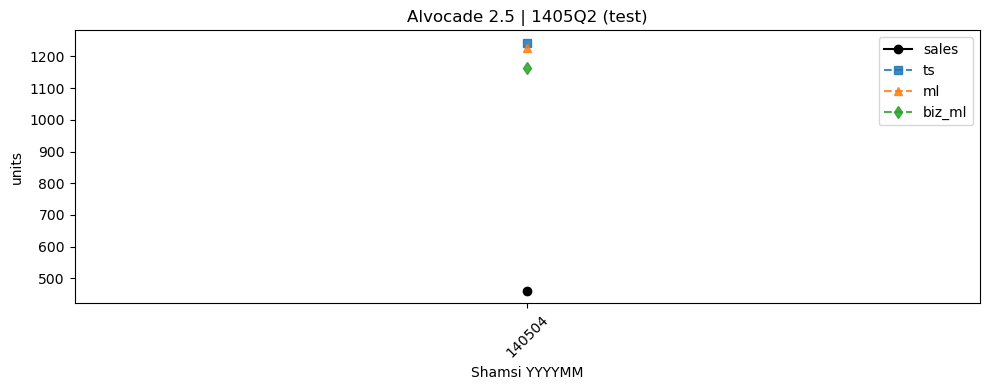

,model,rmse,mae,mape,wmape
0,ts,782.000000,782.000000,169.631236,169.631236
1,ml,764.088818,764.088818,165.745947,165.745947
2,biz_ml,700.999321,700.999321,152.060590,152.060590


In [13]:
# Manual fallback (always works): edit PRODUCT / QRT in the previous cell, then run this
from IPython.display import display

view = (
    compare_df[(compare_df["product"] == PRODUCT) & (compare_df["qrt"] == QRT)]
    .sort_values("date")
    .copy()
)
if view.empty:
    raise ValueError(
        f"No rows for product={PRODUCT!r}, qrt={QRT!r}. "
        f"Try products like {available_products[:5]} / qrts {available_qrts}"
    )

cols = ["date", "horizon", "sales", "ts", "ml", "biz_ml", "residual", "split"]
display(view[cols].reset_index(drop=True))

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(view["date"].astype(str), view["sales"], "o-", label="sales", color="black")
ax.plot(view["date"].astype(str), view["ts"], "s--", label="ts", alpha=0.85)
ax.plot(view["date"].astype(str), view["ml"], "^--", label="ml", alpha=0.85)
ax.plot(view["date"].astype(str), view["biz_ml"], "d--", label="biz_ml", alpha=0.85)
ax.set_title(f"{PRODUCT} | {QRT} ({view['split'].iloc[0]})")
ax.set_xlabel("Shamsi YYYYMM")
ax.set_ylabel("units")
ax.legend()
ax.tick_params(axis="x", rotation=45)
fig.tight_layout()
plt.show()

pd.DataFrame(
    [
        metrics_block(view["sales"], view["ts"], "ts"),
        metrics_block(view["sales"], view["ml"], "ml"),
        metrics_block(view["sales"], view["biz_ml"], "biz_ml"),
    ]
)

In [14]:



rts

NameError: name 'rts' is not defined